# Validation

This notebook contains the ex-post validation code and creates the SI figures for the correlation and leave-one-out analyses.

In [9]:
# General-purpose imports
from concurrent.futures import ProcessPoolExecutor, as_completed
import copy
import multiprocessing as mp
import os
basepath = os.path.expanduser('~')
os.chdir(f"{basepath}/ccvi-data")

import cmcrameri.cm as cmc
import matplotlib as mpl
mpl.rcParams['path.simplify'] = False
from matplotlib.collections import EllipseCollection
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np
from panel_imputer import PanelImputer
import pandas as pd
import seaborn as sns

import ccvi
from utils.data_processing import winsorization_normalization

In [10]:
# load the data
fp = ccvi.config.get_global_config()["storage_path"]
scores = pd.read_parquet(os.path.join(fp, 'output/2025_Q3/ccvi_scores_2025_Q3.parquet'))
exposure = pd.read_parquet(os.path.join(fp, 'output/exposure.parquet'))
scores = scores.join(exposure)
scores

CLI  CLI_current  CLI_accumulated  CLI_longterm  \
pgid   year quarter                                                         
49901  2015 1        0.012179     0.006827         0.013243      0.011202   
            2        0.013450     0.010112         0.013347      0.011077   
            3        0.013582     0.010112         0.013624      0.011138   
            4        0.011873     0.005902         0.013668      0.010916   
       2016 1        0.014059     0.011411         0.013809      0.010878   
...                       ...          ...              ...           ...   
250133 2024 3        0.000000     0.000000         0.000000      0.000000   
            4        0.000000     0.000000         0.000000      0.000000   
       2025 1        0.000000     0.000000         0.000000      0.000000   
            2        0.000000     0.000000         0.000000      0.000000   
            3        0.000000     0.000000         0.000000      0.000000   

                     CLI_current_floods  CLI_current_cyclones  \
pgid   year quarter                                             
49901  2015 1                  0.000000                   0.0   
            2                  0.000000                   0.0   
            3                  0.000000                   0.0   
            4                  0.000000                   0.0   
       2016 1                  0.469504                   0.0   
...                                 ...                   ...   
250133 2024 3                  0.000000                   0.0   
            4                  0.000000                   0.0   
       2025 1                  0.000000                   0.0   
            2                  0.000000                   0.0   
            3                  0.000000                   0.0   

                     CLI_current_heavy-precipitation  CLI_current_heatwave  \
pgid   year quarter                                                          
49901  2015 1                               0.333333                   0.0   
            2                               0.500000                   0.0   
            3                               0.500000                   0.0   
            4                               0.277778                   0.0   
       2016 1                               0.277778                   0.0   
...                                              ...                   ...   
250133 2024 3                               0.000000                   0.0   
            4                               0.000000                   0.0   
       2025 1                               0.000000                   0.0   
            2                               0.000000                   0.0   
            3                               0.000000                   0.0   

                     CLI_current_wildfires  CLI_current_drought  ...  \
pgid   year quarter                                              ...   
49901  2015 1                          0.0             0.050025  ...   
            2                          0.0             0.000000  ...   
            3                          0.0             0.000000  ...   
            4                          0.0             0.087927  ...   
       2016 1                          0.0             0.045601  ...   
...                                    ...                  ...  ...   
250133 2024 3                          0.0                  NaN  ...   
            4                          0.0                  NaN  ...   
       2025 1                          0.0                  NaN  ...   
            2                          0.0                  NaN  ...   
            3                          0.0                  NaN  ...   

                     VUL_environmental_biodiversity  \
pgid   year quarter                                   
49901  2015 1                              0.050890   
            2                              0.050731   
      

## Intercorrelation Analysis

Intercorrelation analysis checks correlations along the index hierarchy, testing the appropriateness of our conceptually driven choices. Generally, we want to see less correlations; existing correlations should be confined to within a given level of the hierarchy. While high correlations can signify inappropriate indicator selection, it can also reflect existing multidimensional phenomena, such as overlapping vulnerabilities.

### Setup

In [11]:
def create_masks(corr):
    """Creates masks to differentiate within-level correlations in the index hierarchy
    from across-level correlation based on the correlation matrix.
    """
    mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
    mask_alpha = pd.DataFrame(index=corr.index, columns=corr.columns, data=mask.copy())
    mask_data = pd.DataFrame(index=corr.index, columns=corr.columns, data=mask.copy())
    for i, r in corr.iterrows():
        for j, _ in r.items():
            if i[:i.rfind("_")] == j[:j.rfind("_")]:
                mask_alpha.at[i, j] = True
            else:
                mask_data.at[i, j] = True
    return mask_data, mask_alpha

def plot_corr_ellipses(data, ax, mask=None, **kwargs) -> EllipseCollection:
    """ Plots elipses with the shape corresponding to the strenght of the correlation.
    Adapted from https://stackoverflow.com/questions/34556180/how-can-i-plot-a-correlation-matrix-as-a-set-of-ellipses-similar-to-the-r-open.
    """
    M = np.asarray(data)
    if M.ndim != 2:
        raise ValueError("data must be a 2D array")

    if mask is None:
        keep = np.ones(M.shape, dtype=bool)
    else:
        keep = np.asarray(mask)
        if keep.shape != M.shape:
            raise ValueError("mask must have same shape as data")
        keep = keep.astype(bool)

    # xy centers
    xy_all = np.indices(M.shape)[::-1].reshape(2, -1).T + 0.5
    keep_flat = keep.ravel()

    xy = xy_all[keep_flat]
    vals = M.ravel()[keep_flat]

    # ellipse parameters
    w = np.ones_like(vals)
    h = 1 - np.abs(vals)
    a = 45 * np.sign(vals)

    ec = EllipseCollection(
        widths=w,
        heights=h,
        angles=a,
        units='x',
        offsets=xy,
        transOffset=ax.transData,
        array=vals,
        **kwargs
    )
    ec.set_clim(-1, 1)
    ax.add_collection(ec)

    return ec

# global kwargs for all correlation plots
outside_group_alpha = 0.6
shared_kwargs = {"vmin":-1, "vmax":1, "linewidths":.5, "square":True, "annot":True, "cmap":cmc.vik, "center":0, "fmt":".2f"}


### Figure S3: Correlation Matrix for Climate Hazard Indicators

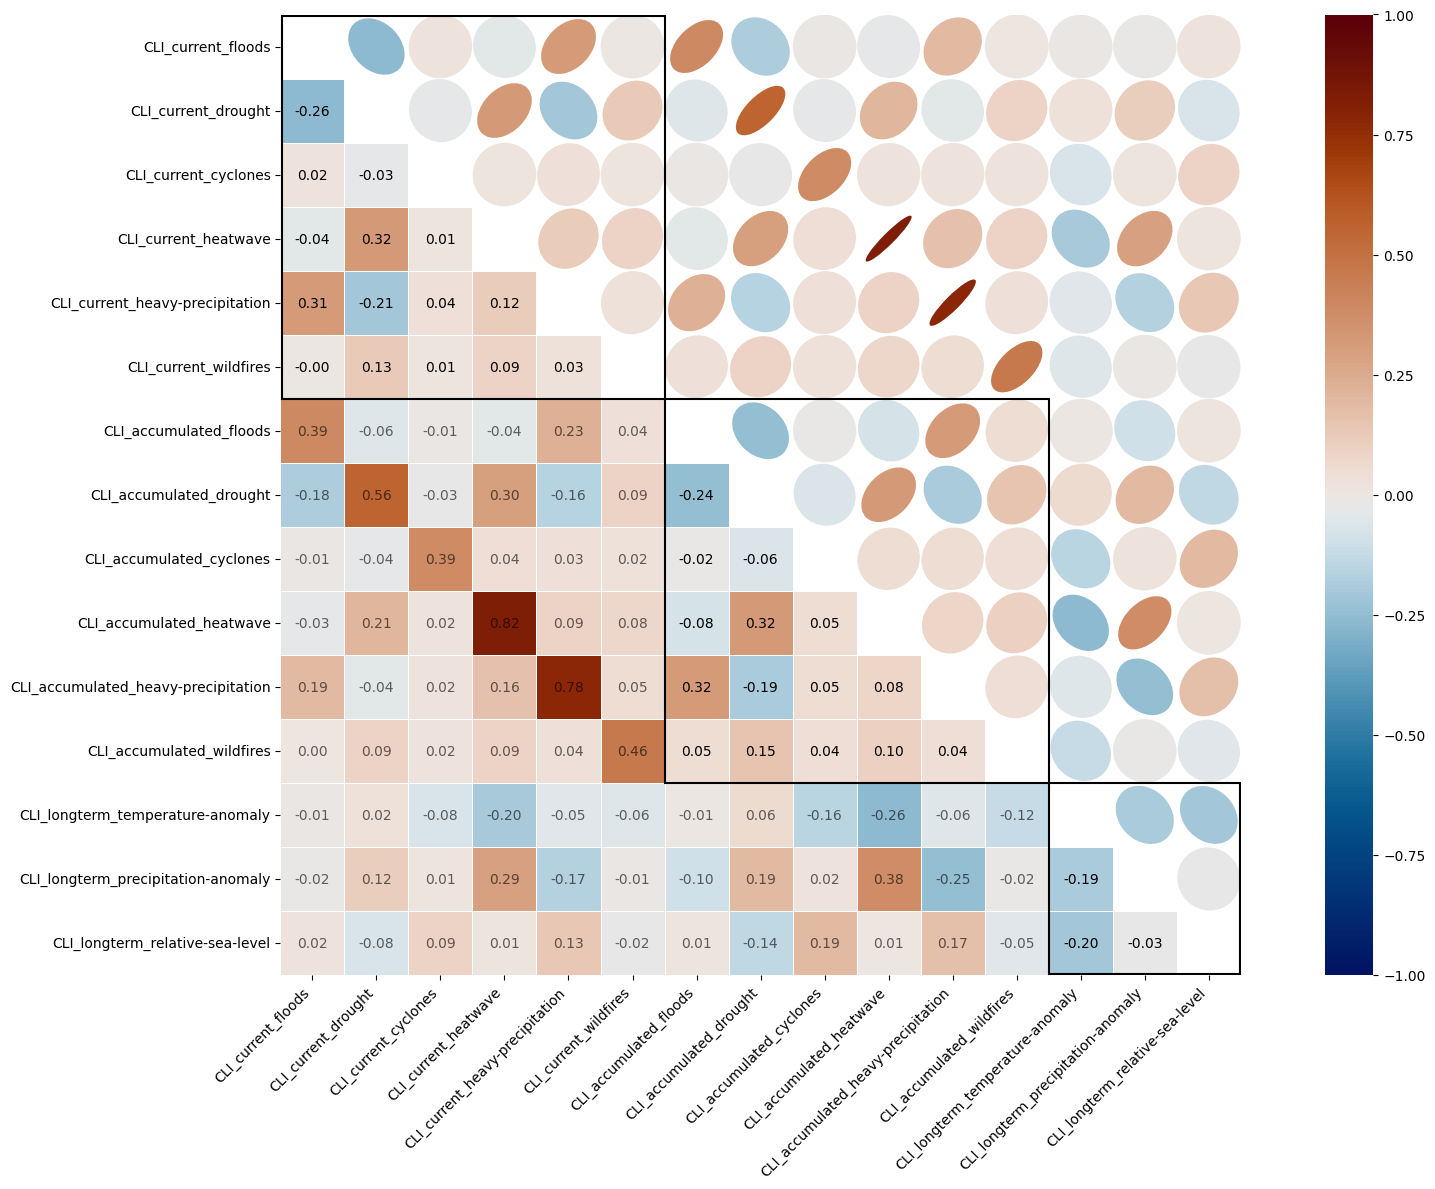

In [12]:
columns_climate = [
    # Dimension 1: Current events
    'CLI_current_floods',
    'CLI_current_drought',
    'CLI_current_cyclones',
    'CLI_current_heatwave',
    'CLI_current_heavy-precipitation',
    'CLI_current_wildfires',
    
    # Dimension 2: Accumulated events
    'CLI_accumulated_floods',
    'CLI_accumulated_drought',
    'CLI_accumulated_cyclones',
    'CLI_accumulated_heatwave',
    'CLI_accumulated_heavy-precipitation',
    'CLI_accumulated_wildfires',
    
    # Dimension 3: Long-term trends
    'CLI_longterm_temperature-anomaly',
    'CLI_longterm_precipitation-anomaly',
    'CLI_longterm_relative-sea-level',
]

# Filter and drop missing data
df_cli_indicators = scores[columns_climate]
plt.figure(figsize=(18, 12))
corr = df_cli_indicators.corr()
mask_data, mask_alpha = create_masks(corr)
sns.heatmap(corr, mask=mask_alpha, xticklabels=False, yticklabels=False, cbar=False, annot_kws={"fontdict":{"alpha":outside_group_alpha, "c":"black"}}, **shared_kwargs)
ax = sns.heatmap(corr, mask=mask_data, xticklabels=True, yticklabels=True, annot_kws={"fontdict":{"c":"black"}}, **shared_kwargs)
plot_corr_ellipses(corr, mask = mask_data & mask_alpha, cmap=shared_kwargs["cmap"], ax = ax)
ax.add_patch(Rectangle((0.02, 0.02), 5.98, 5.98, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((6, 6), 6, 6, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((12, 12), 2.99, 2.99, facecolor="None", edgecolor="black", linewidth=1.5))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("paper/figures/figure_SI2_corr_CLI", dpi=600, bbox_inches="tight")
plt.show()


### Figure S4: Correlation Matrix for Conflict Hazard / Hazards*Exposure Indicators

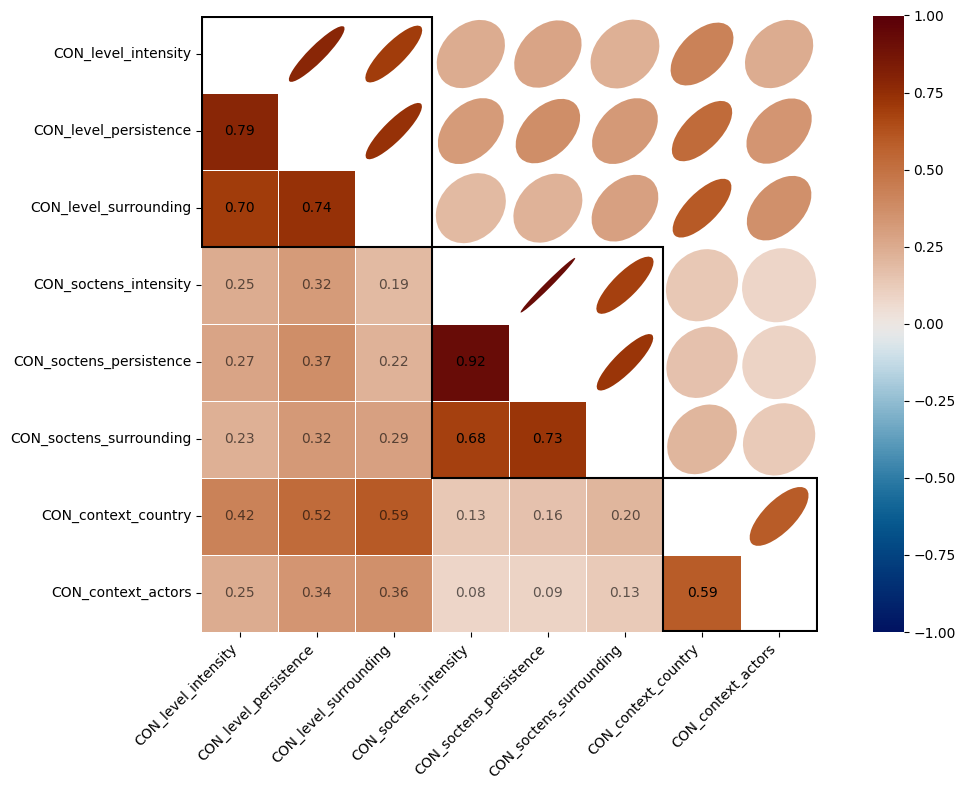

In [13]:
columns_conflict = [
    # Dimension 1: Level of conflict
    'CON_level_intensity',
    'CON_level_persistence',
    'CON_level_surrounding',
    
    # Dimension 2: Level of societal tensions
    'CON_soctens_intensity',
    'CON_soctens_persistence',
    'CON_soctens_surrounding',
    
    # Dimension 3: Conflict context
    'CON_context_country',
    'CON_context_actors'
]

# Filter and drop missing data
df_con_indicators = scores[columns_conflict]

plt.figure(figsize=(12, 8))
corr = df_con_indicators.corr()
mask_data, mask_alpha = create_masks(corr)
sns.heatmap(corr, mask=mask_alpha, xticklabels=False, yticklabels=False, cbar=False, annot_kws={"fontdict":{"alpha":outside_group_alpha, "c":"black"}}, **shared_kwargs)
ax = sns.heatmap(corr, mask=mask_data, xticklabels=True, yticklabels=True, annot_kws={"fontdict":{"c":"black"}}, **shared_kwargs)
plot_corr_ellipses(corr, mask = mask_data & mask_alpha, cmap=shared_kwargs["cmap"], ax = ax)
plt.xticks(rotation=45, ha='right')
ax.add_patch(Rectangle((0.01, 0.02), 2.99, 2.98, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((3, 3), 3, 3, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((6,6), 1.99, 1.99, facecolor="None", edgecolor="black", linewidth=1.5))
plt.tight_layout()
plt.savefig("paper/figures/figure_SI3_corr_CON", dpi=600, bbox_inches="tight")
plt.show()


### Figure S5: Correlation Matrix for Vulnerability Indicators

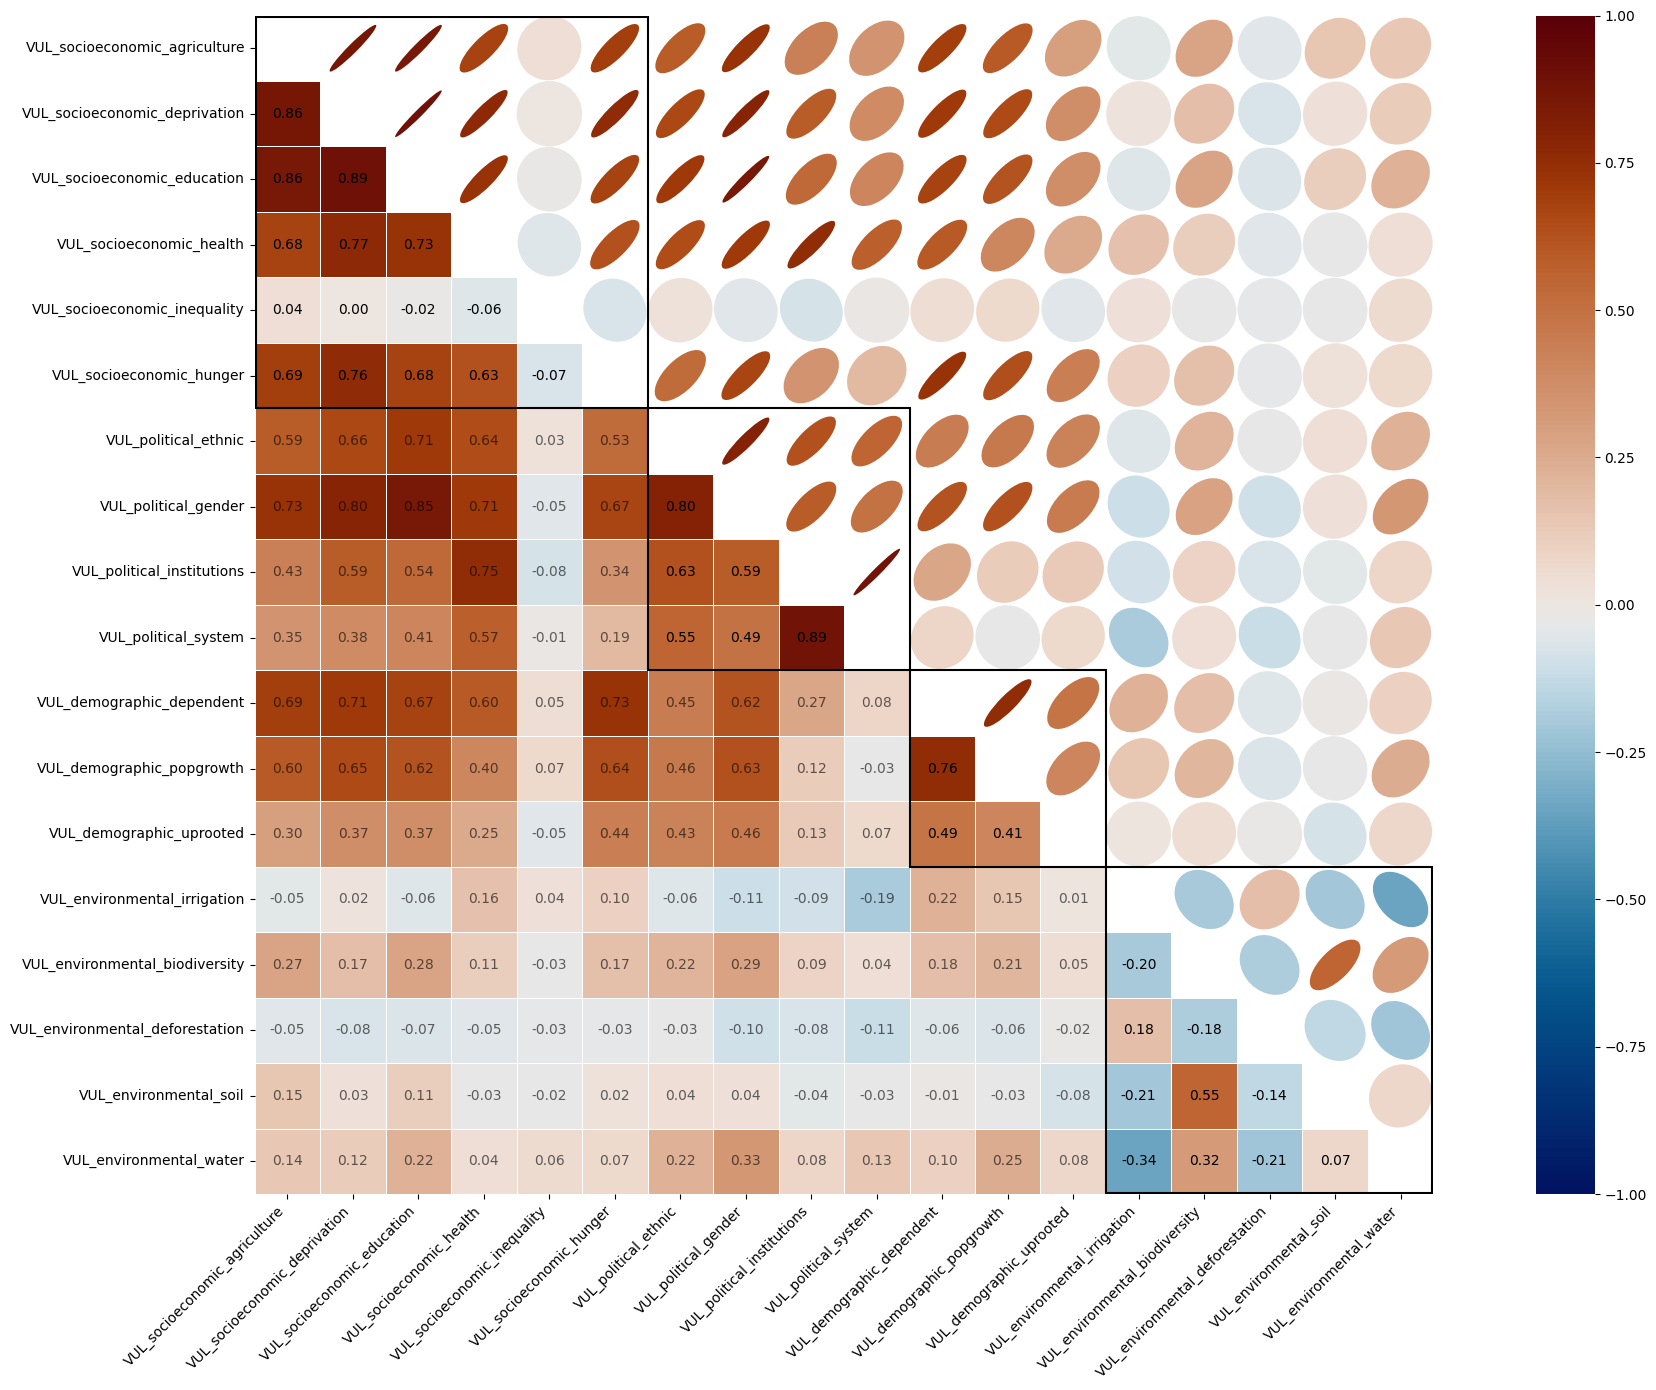

In [14]:
columns_vulnerability = [
    # Dim 1: socio-economic
    'VUL_socioeconomic_agriculture',
    'VUL_socioeconomic_deprivation',
    'VUL_socioeconomic_education',
    'VUL_socioeconomic_health',
    'VUL_socioeconomic_inequality',
    'VUL_socioeconomic_hunger',
    
    # Dim 2: political
    'VUL_political_ethnic',
    'VUL_political_gender',
    'VUL_political_institutions',
    'VUL_political_system',
    
    # Dim 3: demographic
    'VUL_demographic_dependent',
    'VUL_demographic_popgrowth',
    'VUL_demographic_uprooted',
    
    # Dim 4: environmental
    'VUL_environmental_irrigation',
    'VUL_environmental_biodiversity',
    'VUL_environmental_deforestation',
    'VUL_environmental_soil',
    'VUL_environmental_water'
]

# Filter and drop missing data
df_vul_indicators = scores[columns_vulnerability]

plt.figure(figsize=(21, 14))
corr = df_vul_indicators.corr()
mask_data, mask_alpha = create_masks(corr)
sns.heatmap(corr, mask=mask_alpha, xticklabels=False, yticklabels=False, cbar=False, annot_kws={"fontdict":{"alpha":outside_group_alpha, "c":"black"}}, **shared_kwargs)
ax = sns.heatmap(corr, mask=mask_data, xticklabels=True, yticklabels=True, annot_kws={"fontdict":{"c":"black"}}, **shared_kwargs)
plot_corr_ellipses(corr, mask = mask_data & mask_alpha, cmap=shared_kwargs["cmap"], ax = ax)
plt.xticks(rotation=45, ha='right')
ax.add_patch(Rectangle((0.02, 0.02), 5.98, 5.98, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((6, 6), 4, 4, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((10, 10), 3, 3, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((13, 13), 4.98, 4.98, facecolor="None", edgecolor="black", linewidth=1.5))
plt.tight_layout()
plt.savefig("paper/figures/figure_SI4_corr_VUL", dpi=600, bbox_inches="tight")
plt.show()

### Figure S6: Correlation Matrix for Dimension Scores

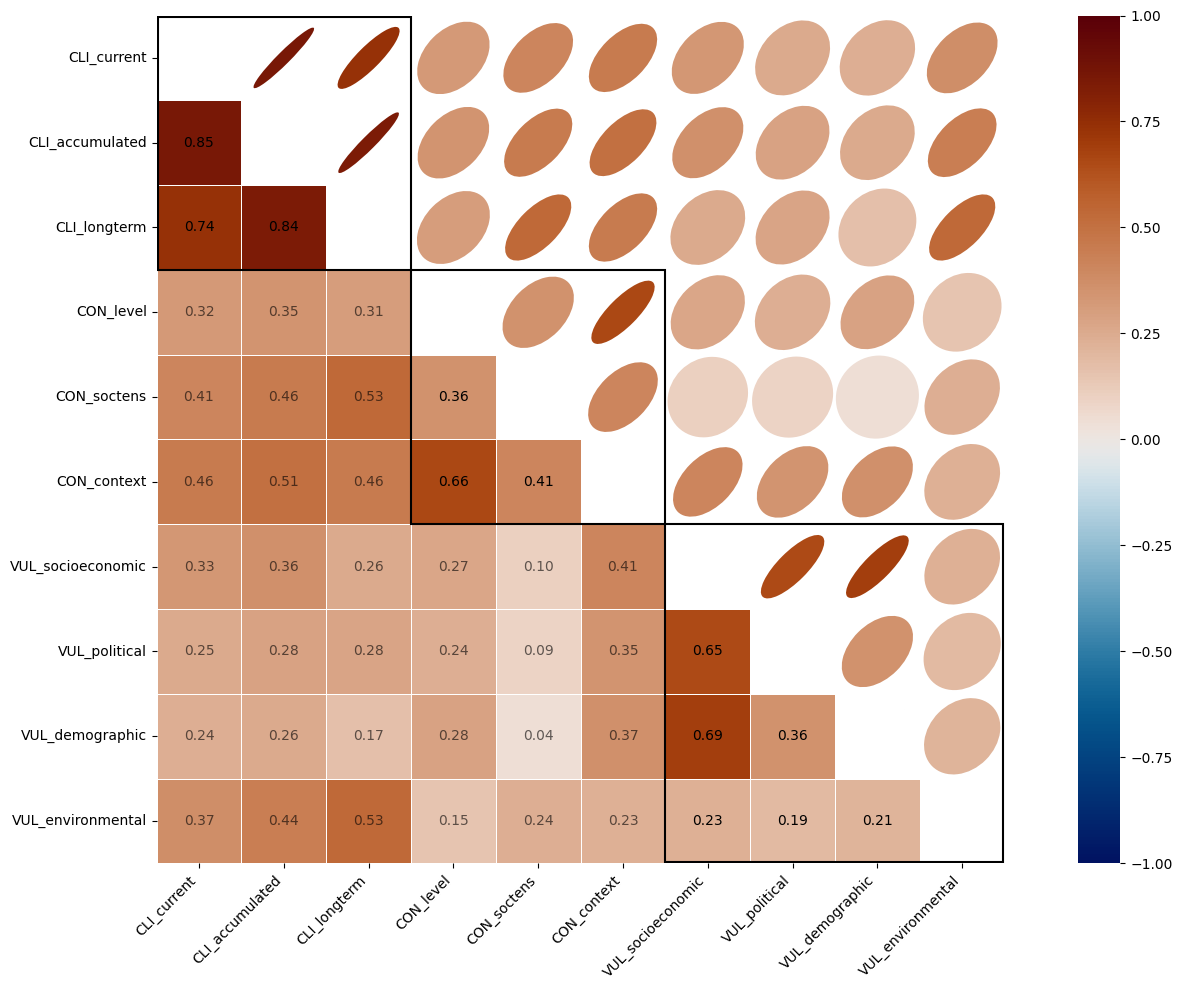

In [15]:
columns_dimensions = [
    # Pillar 1: Climate
    'CLI_current',
    'CLI_accumulated',
    'CLI_longterm',
    
    # Pillar 2: Conflict
    'CON_level',
    'CON_soctens',
    'CON_context',
    
    # Pillar 3: Vulnerability
    'VUL_socioeconomic',
    'VUL_political',
    'VUL_demographic',
    'VUL_environmental',
]

# Filter and drop missing data
df_dimensions = scores[columns_dimensions]

plt.figure(figsize=(15, 10))
corr = df_dimensions.corr()
mask_data, mask_alpha = create_masks(corr)
sns.heatmap(corr, mask=mask_alpha, xticklabels=False, yticklabels=False, cbar=False, annot_kws={"fontdict":{"alpha":outside_group_alpha, "c":"black"}}, **shared_kwargs)
ax = sns.heatmap(corr, mask=mask_data, xticklabels=True, yticklabels=True, annot_kws={"fontdict":{"c":"black"}}, **shared_kwargs)
plot_corr_ellipses(corr, mask = mask_data & mask_alpha, cmap=shared_kwargs["cmap"], ax = ax)
plt.xticks(rotation=45, ha='right')
ax.add_patch(Rectangle((0.02,0.02), 2.98, 2.98, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((3, 3), 3, 3, facecolor="None", edgecolor="black", linewidth=1.5))
ax.add_patch(Rectangle((6, 6), 3.98, 3.98, facecolor="None", edgecolor="black", linewidth=1.5))
plt.tight_layout()
plt.savefig("paper/figures/figure_SI5_corr_DIM", dpi=600, bbox_inches="tight")
plt.show()

## Sensitivity Analysis (Leave-One-Out)

The leave-one-out sensitivity analysis is designed to quantify changes to the aggregate scores when a single indicator is dropped from the index. It works by iteratively dropping individual indicators and recalculating the scores.

### Setup
Build an index of pillars, dimensions, and indicators as well as dictionaries containing the objects from the data pipeline.

In [16]:
pillars = {
    "CLI": ccvi.cli_pillar,
    "CON": ccvi.con_pillar,
    "VUL": ccvi.vul_pillar,
}
dimensions = {}
indicators = {}
index_hierarchy = {}

for pillar in pillars.values():
    index_hierarchy[pillar.composite_id] = {}
    for dim in pillar.components:
        dimensions[dim.composite_id] = dim
        dim_indicators = []
        for ind in dim.components:
            indicators[ind.composite_id] = ind
            dim_indicators.append(ind.composite_id)        
        index_hierarchy[pillar.composite_id][dim.composite_id] = dim_indicators

Select CCVI components only and perform forward-filling to match the CCVI logic for aggregate scores.

In [17]:
# drop raw and exposure scores
df_all = scores.drop(columns=[c for c in scores.columns if "EXP" in c or c.endswith("_raw") or c.endswith("_exposure")])
# Forward-fill indicator time series
imputer = PanelImputer(
    time_index=["year", "quarter"],
    location_index="pgid",
    imputation_method="ffill",
    parallelize=True,
)

# Globals for parallel workers 
df_all = imputer.fit_transform(df_all)  # type: ignore
DF_BASE = df_all
RISK_CONFIG = ccvi.config.all_config["aggregation"]["RISK"]

DF_BASE

CLI  CLI_current  CLI_accumulated  CLI_longterm  \
pgid   year quarter                                                         
49901  2015 1        0.012179     0.006827         0.013243      0.011202   
            2        0.013450     0.010112         0.013347      0.011077   
            3        0.013582     0.010112         0.013624      0.011138   
            4        0.011873     0.005902         0.013668      0.010916   
       2016 1        0.014059     0.011411         0.013809      0.010878   
...                       ...          ...              ...           ...   
250133 2024 3        0.000000     0.000000         0.000000      0.000000   
            4        0.000000     0.000000         0.000000      0.000000   
       2025 1        0.000000     0.000000         0.000000      0.000000   
            2        0.000000     0.000000         0.000000      0.000000   
            3        0.000000     0.000000         0.000000      0.000000   

                     CLI_current_floods  CLI_current_cyclones  \
pgid   year quarter                                             
49901  2015 1                  0.000000                   0.0   
            2                  0.000000                   0.0   
            3                  0.000000                   0.0   
            4                  0.000000                   0.0   
       2016 1                  0.469504                   0.0   
...                                 ...                   ...   
250133 2024 3                  0.000000                   0.0   
            4                  0.000000                   0.0   
       2025 1                  0.000000                   0.0   
            2                  0.000000                   0.0   
            3                  0.000000                   0.0   

                     CLI_current_heavy-precipitation  CLI_current_heatwave  \
pgid   year quarter                                                          
49901  2015 1                               0.333333                   0.0   
            2                               0.500000                   0.0   
            3                               0.500000                   0.0   
            4                               0.277778                   0.0   
       2016 1                               0.277778                   0.0   
...                                              ...                   ...   
250133 2024 3                               0.000000                   0.0   
            4                               0.000000                   0.0   
       2025 1                               0.000000                   0.0   
            2                               0.000000                   0.0   
            3                               0.000000                   0.0   

                     CLI_current_wildfires  CLI_current_drought  ...  \
pgid   year quarter                                              ...   
49901  2015 1                          0.0             0.050025  ...   
            2                          0.0             0.000000  ...   
            3                          0.0             0.000000  ...   
            4                          0.0             0.087927  ...   
       2016 1                          0.0             0.045601  ...   
...                                    ...                  ...  ...   
250133 2024 3                          0.0                  NaN  ...   
            4                          0.0                  NaN  ...   
       2025 1                          0.0                  NaN  ...   
            2                          0.0                  NaN  ...   
            3                          0.0                  NaN  ...   

                     VUL_demographic_popgrowth  VUL_demographic_uprooted  \
pgid   year quarter                                                        
49901  2015 1                         0.283693                  0.002622  

Leave on out functions

In [18]:
def adjust_aggregation_config(aggregate_obj: ccvi.Dimension | ccvi.Pillar, remaining_components: list[str]) -> dict:
    """Adjusts aggregation weights where necessary."""
    cfg = copy.deepcopy(aggregate_obj.aggregation_config)
    weights = cfg.get("weights")
    if isinstance(weights, dict):
        cfg["weights"] = {k: v for k, v in weights.items() if k in remaining_components}
    return cfg


def add_exposure(dim: ccvi.Dimension, df_indicators: pd.DataFrame) -> pd.DataFrame:
    """Applies the exposure layer in case of a ExposureDimension."""
    if not getattr(dim, "has_exposure", False):
        return df_indicators

    exposure_layer = "EXP_pop_density"
    df_exposure = scores[[exposure_layer]].copy()
    df = df_indicators.join(df_exposure, how="left")
    normalization_kwargs = {"limits": [0, 0.999], "ignore_zeroes_limit": True}

    for col in df_indicators.columns:
        exposure_col = f"{col}_exposure"
        df[exposure_col] = (df[col] * df[exposure_layer]).apply(np.log1p)
        df[exposure_col] = winsorization_normalization(df[exposure_col], **normalization_kwargs)

    exposure_cols = [f"{col}_exposure" for col in df_indicators.columns]
    return df[exposure_cols]


def compute_loo_scores(drop_id: str, level: str = "indicator") -> dict[str, pd.DataFrame]:
    """Recomputes aggregate scores when dropping a single indicator or dimension.
    
    Two modes, for which the function identifies the affected aggregate components
    and recomputes them, while re-using existing scores otherwise.
    - level="indicator": drops a single indicator.
    - level="dimension": drops a whole dimension.
    """
    df_source = DF_BASE
    # use composite id logic
    if level == "indicator":
        if drop_id not in indicators:
            raise KeyError(f"Unknown indicator: {drop_id}")

        # Identify dimension/pillar
        ind = indicators[drop_id]
        pillar_id = ind.pillar
        dim_id = "_".join([pillar_id, ind.dim])
        dim = dimensions[dim_id]

        df_loo = df_source.copy()
        # Recompute the dimension
        dim_indicators = index_hierarchy[pillar_id][dim_id]
        remaining_inds = [i for i in dim_indicators if i != drop_id]
        dim_cfg = adjust_aggregation_config(dim, remaining_inds)
        dim_input = df_source[remaining_inds]
        dim_input = add_exposure(dim, dim_input)
        df_loo[dim_id] = ccvi.ccvi.aggregate(dim_input, dim_id, dim_cfg)[dim_id]
        # Recompute the pillar
        pillar = pillars[pillar_id]
        pillar_dims = [d.composite_id for d in pillar.components]
        df_loo[pillar_id] = ccvi.ccvi.aggregate(df_loo[pillar_dims], pillar_id, pillar.aggregation_config)[pillar_id]

    elif level == "dimension":
        if drop_id not in dimensions:
            raise KeyError(f"Unknown dimension: {drop_id}")

        # Identify dimension/pillar
        dim = dimensions[drop_id]
        pillar_id = dim.pillar
        pillar = pillars[pillar_id]

        df_loo = df_source.copy()
        # Recompute the pillar
        remaining_dims = [d.composite_id for d in pillar.components if d.composite_id != drop_id]
        pillar_cfg = adjust_aggregation_config(pillar, remaining_dims)
        df_loo[pillar_id] = ccvi.ccvi.aggregate(df_loo[remaining_dims], pillar_id, pillar_cfg)[pillar_id]

    else:
        raise ValueError('level must be "indicator" or "dimension"')

    # Recompute affected risk scores
    if pillar_id in {"CLI", "VUL"}:
        df_loo["CLI_risk"] = ccvi.ccvi.aggregate(df_loo[["CLI", "VUL"]], "CLI_risk", RISK_CONFIG["CLI_risk"])["CLI_risk"]
    if pillar_id in {"CON", "VUL"}:
        df_loo["CON_risk"] = ccvi.ccvi.aggregate(df_loo[["CON", "VUL"]], "CON_risk", RISK_CONFIG["CON_risk"])["CON_risk"]

    # Recompute CCVI score
    df_loo["CCVI"] = ccvi.ccvi.aggregate(df_loo[["CLI_risk", "CON_risk"]], "CCVI", RISK_CONFIG["CCVI"])["CCVI"]

    delta = df_loo[["CLI_risk", "CON_risk", "CCVI"]] - DF_BASE[["CLI_risk", "CON_risk", "CCVI"]]
    
    return {drop_id: delta}

def create_loo_summary(drop_id: str, df_delta: pd.DataFrame) -> dict:
    """Creates summary for one leave-one-out run."""
    results_summary = {
        "ID": drop_id,
        "CLI_risk_delta_mean": df_delta["CLI_risk"].mean(),
        "CLI_risk_delta_std": df_delta["CLI_risk"].std(),
        "CLI_risk_delta_abs_mean": df_delta["CLI_risk"].abs().mean(),
        "CLI_risk_delta_abs_std": df_delta["CLI_risk"].abs().std(),
        "CON_risk_delta_mean": df_delta["CON_risk"].mean(),
        "CON_risk_delta_std": df_delta["CON_risk"].std(),
        "CON_risk_delta_abs_mean": df_delta["CON_risk"].abs().mean(),
        "CON_risk_delta_abs_std": df_delta["CON_risk"].abs().std(),
        "CCVI_delta_mean": df_delta["CCVI"].mean(),
        "CCVI_delta_std": df_delta["CCVI"].std(),
        "CCVI_delta_abs_mean": df_delta["CCVI"].abs().mean(),
        "CCVI_delta_abs_std": df_delta["CCVI"].abs().std(),
    }
    return results_summary


### Leave-one-out Calculations

Runs LOO calculations for all indicators and dimensions using parallel processing. This may take a while, depending on the system.

In [19]:
def calculate_loo(level: str, components:dict) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    max_workers = max(1, (os.cpu_count() or 2) - 1)
    loo_results = {}

    total = len(components)
    done = 0
    ctx = mp.get_context("fork")
    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
        futures = [executor.submit(compute_loo_scores, id, level) for id in components]
        for future in as_completed(futures):
            loo_results.update(future.result())
            done += 1
            if done % 5 == 0 or done == total:
                print(f"Level: {level}. Completed: {done}/{total}")

    summaries = [create_loo_summary(k, v) for k, v in loo_results.items()]
    loo_summary = (
        pd.DataFrame(summaries)
        .sort_values("CCVI_delta_abs_mean", ascending=False)
        .reset_index(drop=True)
    )
    return loo_results, loo_summary

loo_results_ind, loo_summary_ind = calculate_loo("indicator", indicators)
loo_results_dim, loo_summary_dim = calculate_loo("dimension", dimensions)


Exception ignored in: <function ResourceTracker.__del__ at 0x7f105eb271a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fdb2a4231a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/usr/local/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f8d8c19f1a0>
Traceback (most recent call last):
  File "/usr

Level: indicator. Completed: 5/41
Level: indicator. Completed: 10/41
Level: indicator. Completed: 15/41
Level: indicator. Completed: 20/41
Level: indicator. Completed: 25/41
Level: indicator. Completed: 30/41
Level: indicator. Completed: 35/41
Level: indicator. Completed: 40/41
Level: indicator. Completed: 41/41
Level: dimension. Completed: 5/10
Level: dimension. Completed: 10/10


### Bar plots: absolute changes by component

Plots the mean absolute change + std from the LOO results.

In [20]:
def plot_abs_change(summary, score_mean_col, score_std_col, title, pillars):
    data = summary.loc[summary["ID"].str.contains("|".join(pillars))].copy()
    if data.empty:
        print(f"No indicators found for pillars: {pillars}")
        return
    data = data.sort_values(score_mean_col, ascending=True)
    y = np.arange(len(data))
    bar_h = 0.3

    plt.figure(figsize=(10, max(6, 0.3 * len(data))))
    plt.barh(y + bar_h / 2, data[score_mean_col], height=bar_h, label="mean abs", color="blue")
    plt.barh(y - bar_h / 2, data[score_std_col], height=bar_h, label="std (signed)", color="lightblue")
    plt.yticks(y, data["ID"])
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Component")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


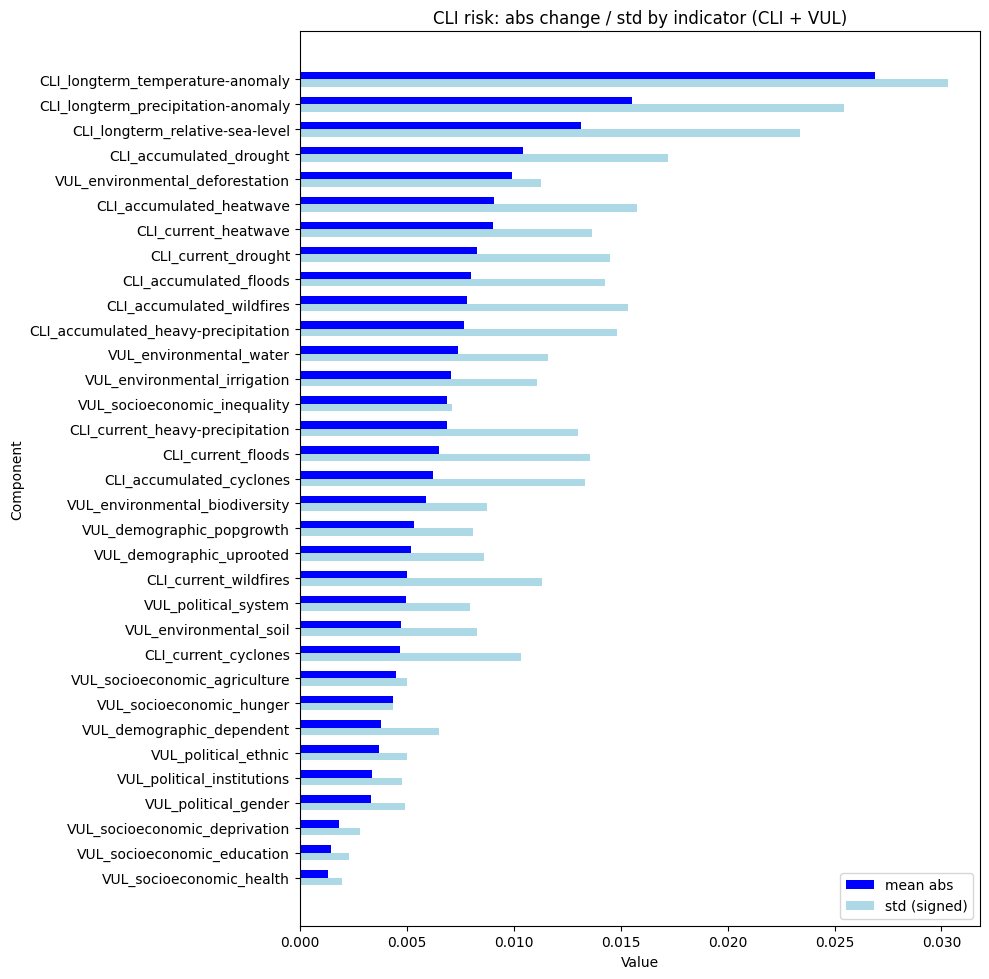

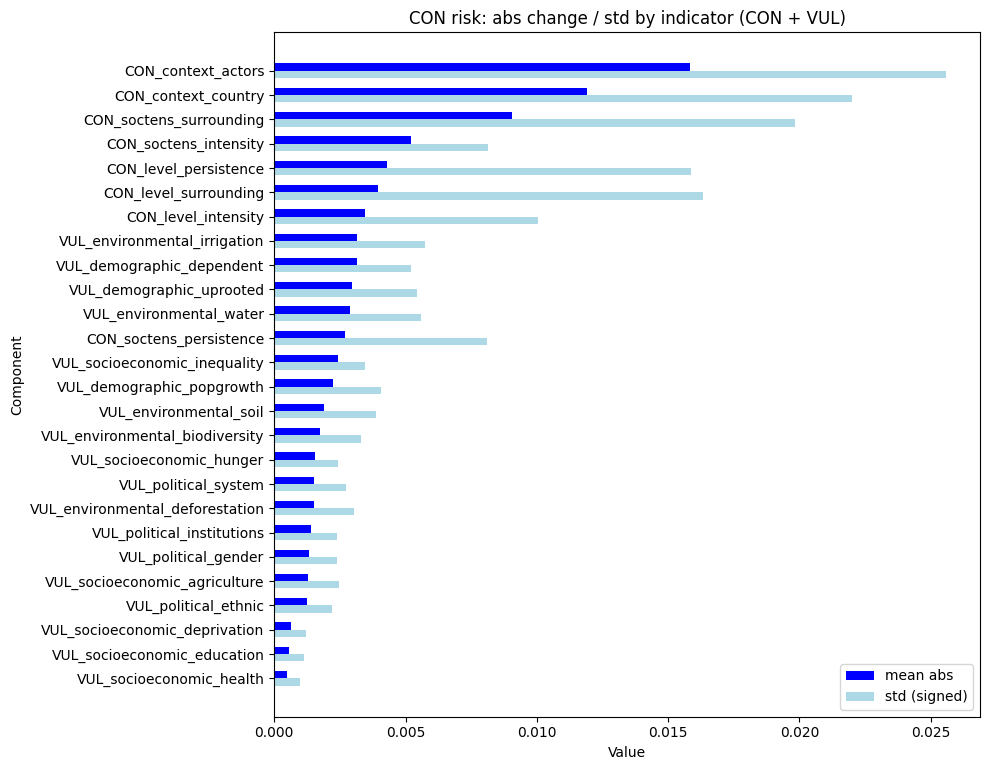

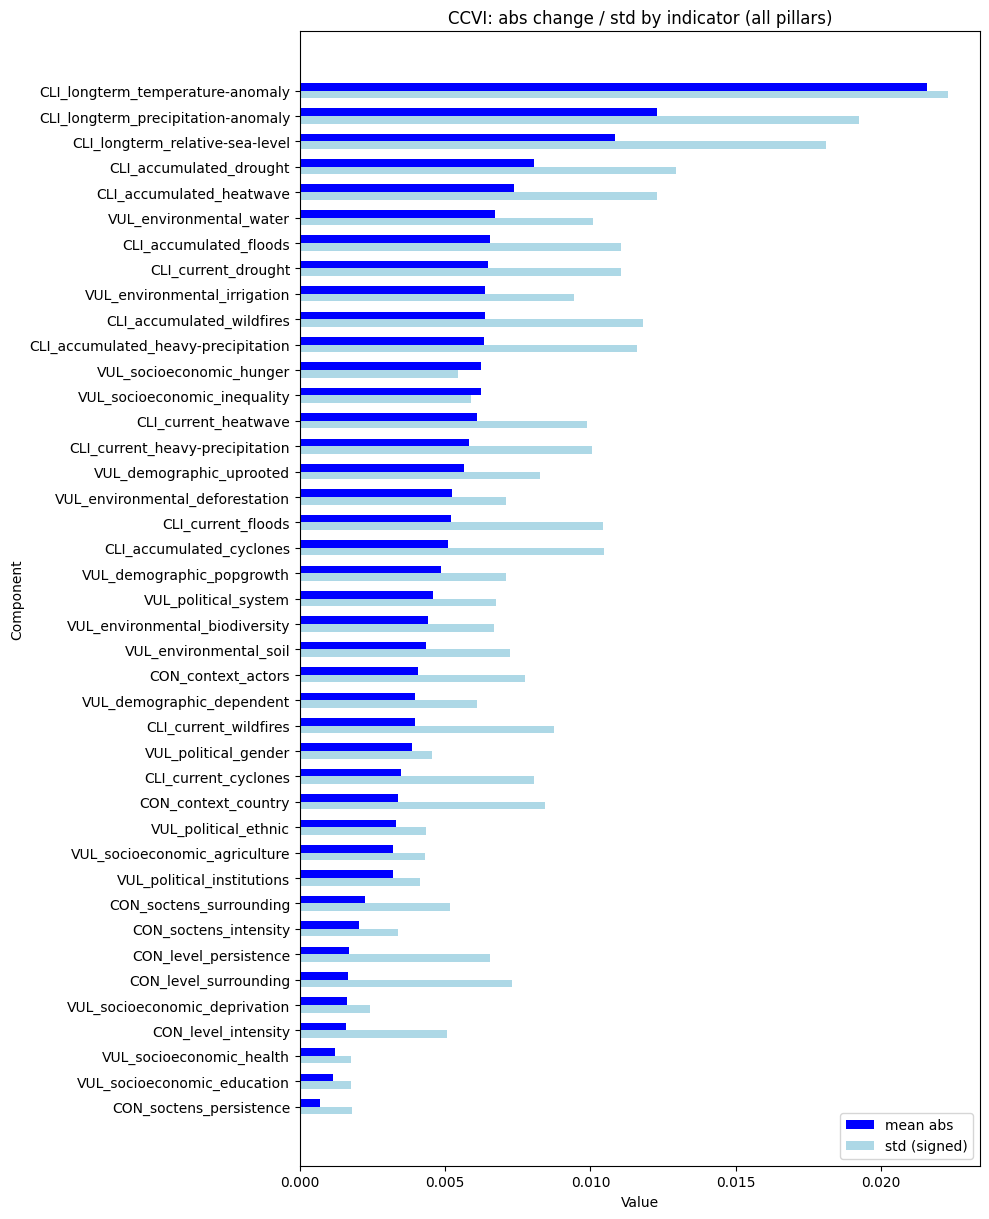

In [21]:
# Indicators
plot_abs_change(
    loo_summary_ind,
    "CLI_risk_delta_abs_mean",
    "CLI_risk_delta_std",
    "CLI risk: abs change / std by indicator (CLI + VUL)",
    ["CLI", "VUL"],
)
plot_abs_change(
    loo_summary_ind,
    "CON_risk_delta_abs_mean",
    "CON_risk_delta_std",
    "CON risk: abs change / std by indicator (CON + VUL)",
    ["CON", "VUL"],
)
plot_abs_change(
    loo_summary_ind,
    "CCVI_delta_abs_mean",
    "CCVI_delta_std",
    "CCVI: abs change / std by indicator (all pillars)",
    ["CLI", "CON", "VUL"],
)


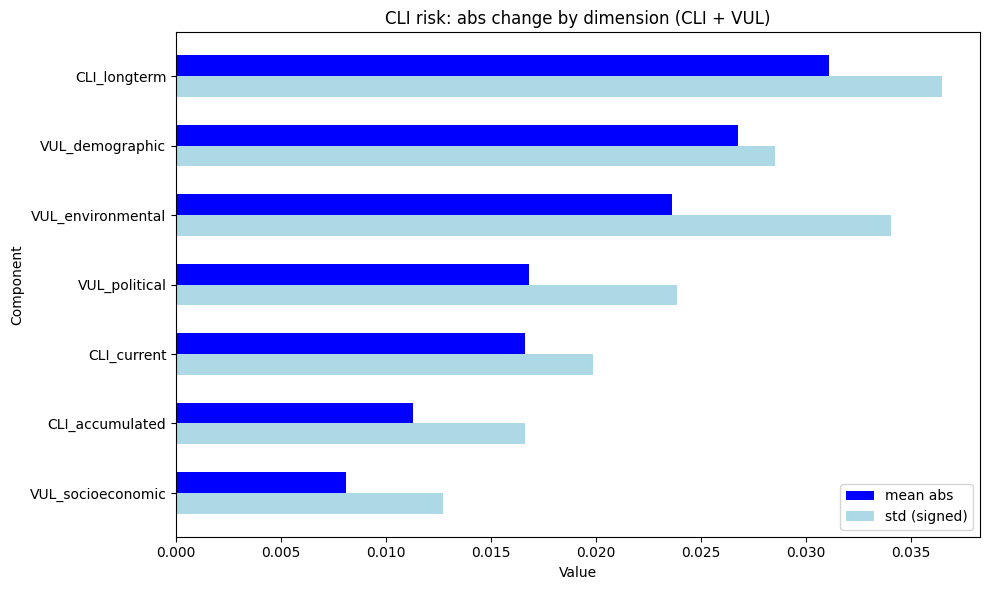

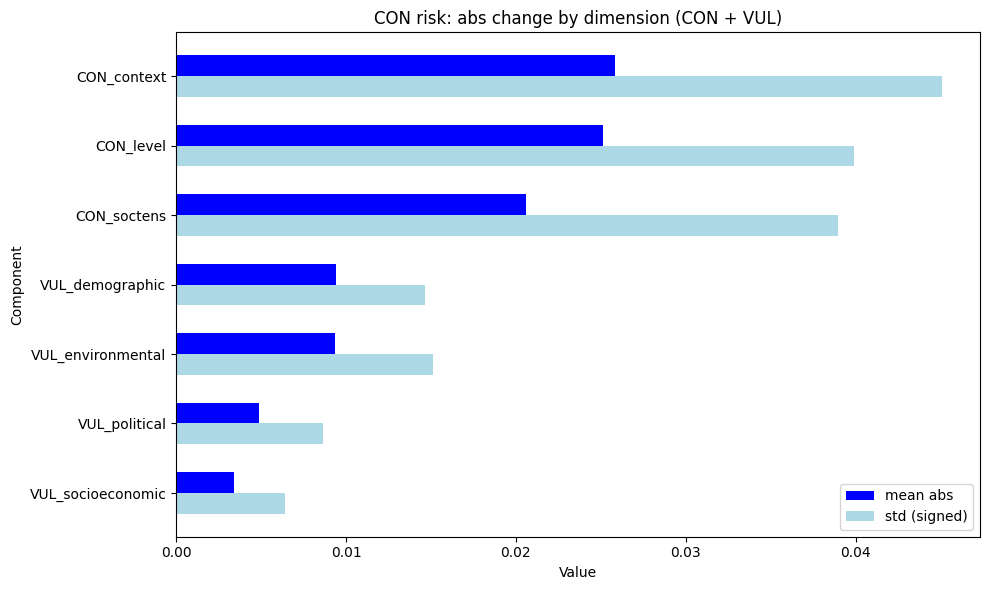

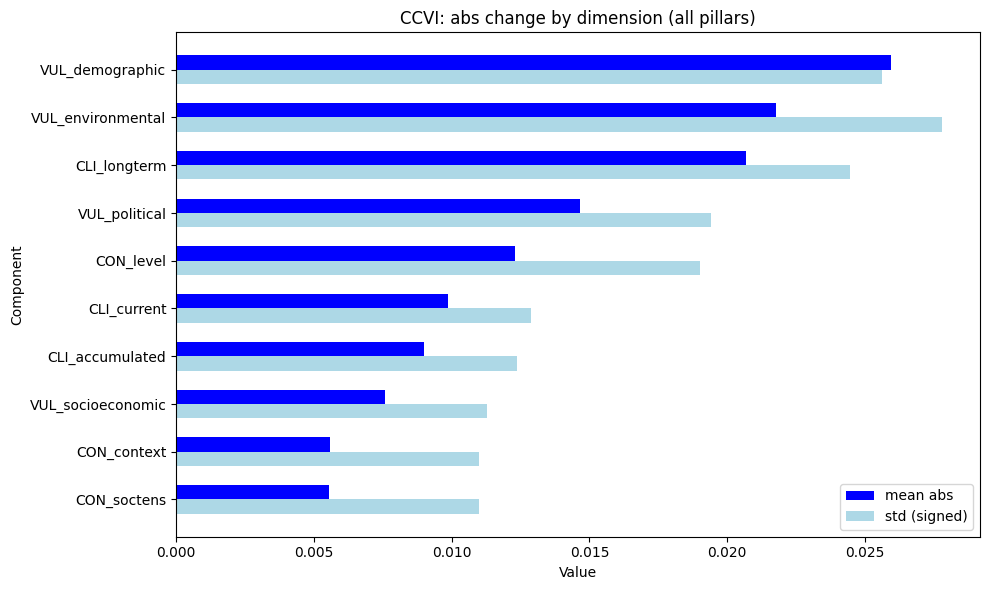

In [22]:
# Dimensions
plot_abs_change(
    loo_summary_dim,
    "CLI_risk_delta_abs_mean",
    "CLI_risk_delta_std",
    "CLI risk: abs change by dimension (CLI + VUL)",
    ["CLI", "VUL"],
)
plot_abs_change(
    loo_summary_dim,
    "CON_risk_delta_abs_mean",
    "CON_risk_delta_std",
    "CON risk: abs change by dimension (CON + VUL)",
    ["CON", "VUL"],
)
plot_abs_change(
    loo_summary_dim,
    "CCVI_delta_abs_mean",
    "CCVI_delta_std",
    "CCVI: abs change by dimension (all pillars)",
    ["CLI", "CON", "VUL"],
)

## Model-wide sensitivity analysis

This visualization compares the sorted values of the risk scores to the minimum/maximum deviations through the LOO analysis, both based on absolute values on their corresponding ranks for a given quarter.


### Setup

In [23]:
def build_impacts_per_score(loo_results: dict) -> tuple[dict, dict]:
    """reshape loo results for model-wide analysis"""
    risk_scores = ["CLI_risk", "CON_risk", "CCVI"]
    
    impacts = {
        score: pd.concat(
            [loo_results[drop_id][score].rename(drop_id) for drop_id in loo_results],
            axis=1,
        )
        for score in risk_scores
    }

    impact_stats = {
        score: {
            "std": impacts[score].std(axis=1, skipna=True),
            "min": impacts[score].min(axis=1, skipna=True).fillna(0),
            "max": impacts[score].max(axis=1, skipna=True).fillna(0),
        }
        for score in risk_scores
    }

    return impacts, impact_stats


def plot_ranked_score_deviations(axes, base_quarter, score, color_base, color_min, color_max, impacts, stats, level):
    """Plotting for ranked-based sensitivity"""
    # value-based sorting
    base_series = base_quarter[score].dropna()
    base_sorted = base_series.sort_values()
    min_sorted = stats[score]["min"].reindex(base_sorted.index).fillna(0)
    max_sorted = stats[score]["max"].reindex(base_sorted.index).fillna(0)

    # rank_based sorting
    score_stack = impacts[score].add(base_series, axis=0)
    base_rank = base_series.rank(method="average")
    base_rank_sorted = base_rank.sort_values()
    rank_stack = score_stack.rank(axis=0, method="average")
    min_rank_sorted = rank_stack.min(axis=1).reindex(base_rank_sorted.index)
    min_rank_sorted = min_rank_sorted.fillna(base_rank_sorted)
    max_rank_sorted = rank_stack.max(axis=1).reindex(base_rank_sorted.index)
    max_rank_sorted = max_rank_sorted.fillna(base_rank_sorted)

    x_val = np.arange(len(base_sorted))
    x_rank = np.arange(len(base_rank_sorted))
    
    labels = { 
        "CON_risk": "Conflict Risk",
        "CLI_risk": "Climate Risk",
        "CCVI": "Combined Risk"
    }

    # Plot 1: values
    axes[0].fill_between(x_val, base_sorted.values, base_sorted.values + min_sorted.values, label="min score", color=color_min, zorder=2, linewidth=0.2, alpha=0.8)
    axes[0].fill_between(x_val, base_sorted.values, base_sorted.values + max_sorted.values, label="max score", color=color_max, zorder=2, linewidth=0.2, alpha=0.8)
    axes[0].plot(x_val, base_sorted.values, label=f"{score} score", color=color_base, zorder=3, linewidth=1)
    axes[0].set_title(f"{labels[score]} Value Sensivity ({level})")
    axes[0].set_ylabel("Score")
    axes[0].yaxis.set_label_coords(-0.07, 0.5)

    # Plot 2: ranks
    axes[1].fill_between(x_rank, base_rank_sorted.values, min_rank_sorted.values, label="min rank", color=color_min, zorder=2, linewidth=0.2, alpha=0.8)
    axes[1].fill_between(x_rank, base_rank_sorted.values, max_rank_sorted.values, label="max rank", color=color_max, zorder=2, linewidth=0.2, alpha=0.8)
    axes[1].plot(x_rank, base_rank_sorted.values, label=f"{score} rank", color=color_base, zorder=3, linewidth=1)
    axes[1].set_title(f"{labels[score]} Rank Sensivity ({level})")
    axes[1].set_ylabel("Rank")
    axes[1].set_ylim(-2500, len(base_sorted.dropna()) + 2500)
    axes[1].yaxis.set_label_coords(-0.07, 0.5)

    for ax in axes:
        ax.set_xlabel("Ranked grid cells (original value)")
        ax.legend(loc="upper left")
        ax.yaxis.grid(True, linestyle="--", alpha=0.5)
        ax.set_xticks([])
        ax.set_xlim(-500, len(base_sorted.dropna()) + 500)

    return


### Figures SI6 & SI7: Model-wide sensitivity based on LOO analysis

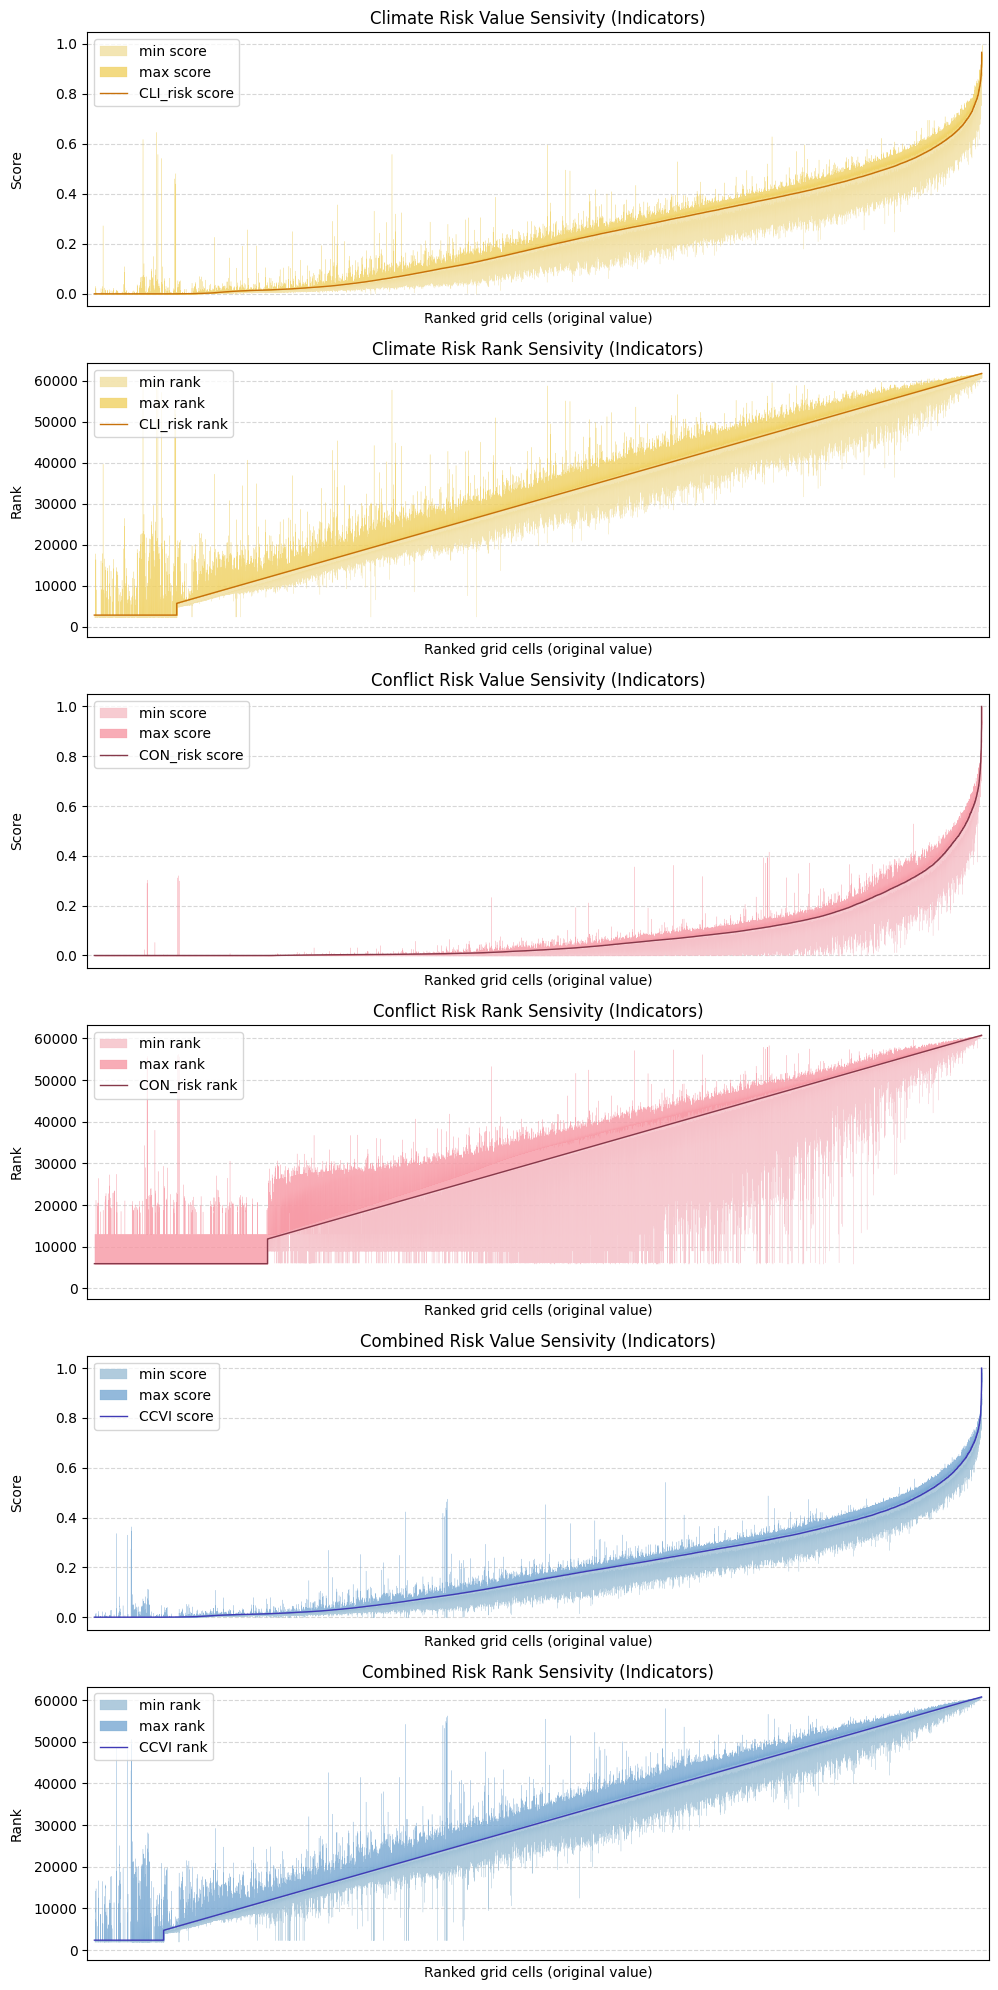

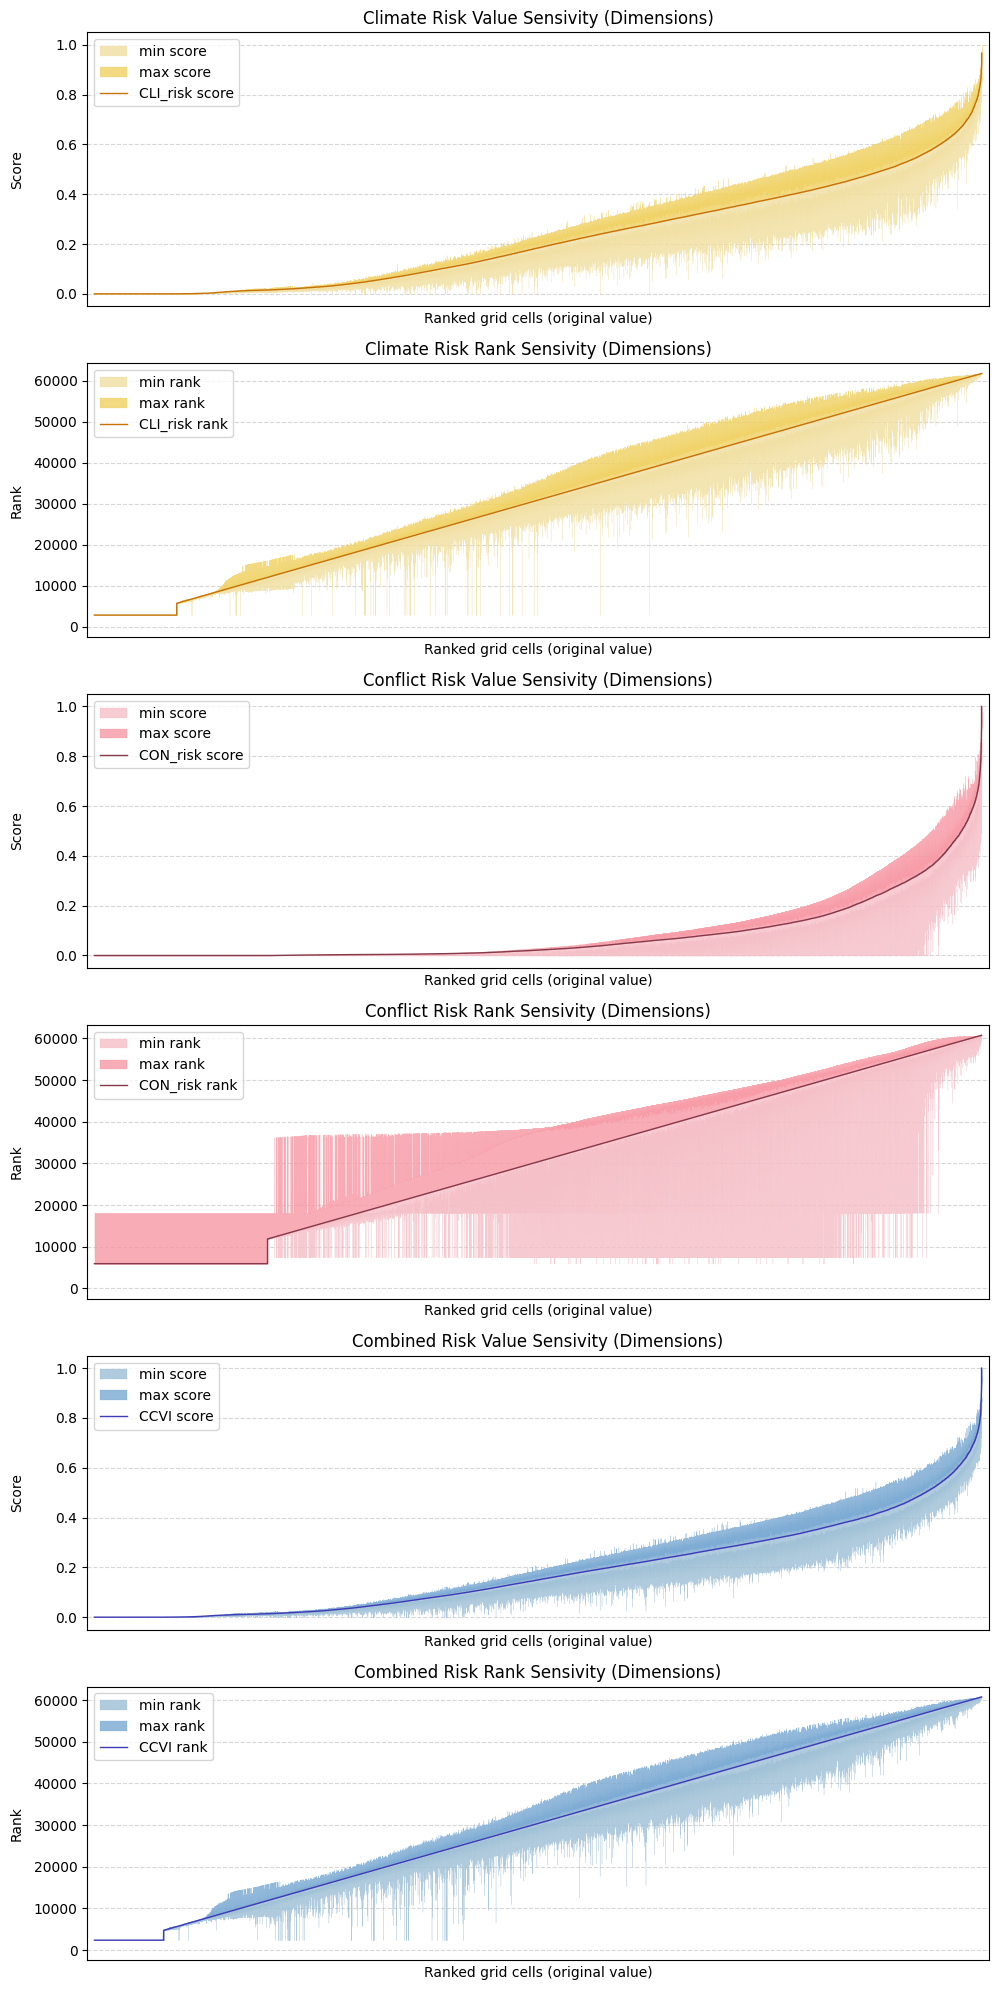

In [24]:

# colors
color_con0 = "#f5bec6"
color_con1 = "#f798a4"
color_con2 = "#86394a"

color_cli0 = "#f1dfa0"
color_cli1 = "#f0d162"
color_cli2 = "#c7710b"

color_ccvi0 = "#9DBFD5"
color_ccvi1 = "#78A8D2"
color_ccvi2 = "#403ab5"

# based on Q3 2025
base_quarter = DF_BASE.xs((2025, 3), level=("year", "quarter"), drop_level=False)

# prep LOO results
impacts_indicator, stats_indicator = build_impacts_per_score(loo_results_ind)
impacts_dimension, stats_dimension = build_impacts_per_score(loo_results_dim)

# Indicator-level plots
fig, axs = plt.subplots(6, 1, figsize=(10, 20))
plot_ranked_score_deviations([axs[0], axs[1]], base_quarter, "CLI_risk", color_cli2, color_cli0, color_cli1, impacts_indicator, stats_indicator, "Indicators")
plot_ranked_score_deviations([axs[2], axs[3]], base_quarter, "CON_risk", color_con2, color_con0, color_con1, impacts_indicator, stats_indicator, "Indicators")
plot_ranked_score_deviations([axs[4], axs[5]], base_quarter, "CCVI", color_ccvi2, color_ccvi0, color_ccvi1, impacts_indicator, stats_indicator, "Indicators")
fig.tight_layout()
plt.savefig("paper/figures/Figure_SI6_LOO_IND", dpi=600, bbox_inches="tight")
plt.show()

# Dimension-level plots
fig, axs = plt.subplots(6, 1, figsize=(10, 20))
plot_ranked_score_deviations([axs[0], axs[1]], base_quarter, "CLI_risk", color_cli2, color_cli0, color_cli1, impacts_dimension, stats_dimension, "Dimensions")
plot_ranked_score_deviations([axs[2], axs[3]], base_quarter, "CON_risk", color_con2, color_con0, color_con1, impacts_dimension, stats_dimension, "Dimensions")
plot_ranked_score_deviations([axs[4], axs[5]], base_quarter, "CCVI", color_ccvi2, color_ccvi0, color_ccvi1, impacts_dimension, stats_dimension, "Dimensions")
fig.tight_layout()
plt.savefig("paper/figures/Figure_SI7_LOO_DIM", dpi=600, bbox_inches="tight")
plt.show()
